In [72]:
import os
import requests
from google.colab import userdata
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
import tensorflow as tf
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler




**Data Preprocessing**

In [73]:
# Cloning Github Repo
token = userdata.get('PAT_education')
repo_url = "https://github.com/maimoua-lee/datasci-207-2026-spring-project-team.git"
authenticated_repo_url = repo_url.replace("https://", f"https://oauth2:{token.strip()}@")
!git clone {authenticated_repo_url}

fatal: destination path 'datasci-207-2026-spring-project-team' already exists and is not an empty directory.


In [74]:
# List the contents of the data directory
!ls -F /content/datasci-207-2026-spring-project-team/src/

 an_pham_project_contribution.ipynb  'Mai Moua Lee.ipynb'
 ewura_project_contribution.ipynb     rishabh_sinha_project_contribution.ipynb


In [75]:
#File Path with cleaned data
file_path = "/content/datasci-207-2026-spring-project-team/data/raw/spotify_data clean.csv"

# Read the CSV file into a pandas DataFrame
df_spotify = pd.read_csv(file_path)

# Display the first 5 rows of the DataFrame
df_spotify.head()

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,NaN,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39


In [76]:
#Extracting release year for analysis purposes
df_spotify['release_year'] = pd.to_datetime(df_spotify['album_release_date']).dt.year
df_spotify.head()

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min,release_year
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55,2025
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07,2025
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,NaN,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55,2025
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69,2025
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39,2025


In [77]:
#Checking missing values
print(df_spotify.isna().sum())

track_id                 0
track_name               0
track_number             0
track_popularity         0
explicit                 0
artist_name              3
artist_popularity        0
artist_followers         0
artist_genres         3361
album_id                 0
album_name               0
album_release_date       0
album_total_tracks       0
album_type               0
track_duration_min       0
release_year             0
dtype: int64


In [78]:
#Verfiying data shape
print(df_spotify.shape)

(8582, 16)


In [79]:
#Veriftying data types
print(df_spotify.dtypes)

track_id               object
track_name             object
track_number            int64
track_popularity        int64
explicit                 bool
artist_name            object
artist_popularity       int64
artist_followers        int64
artist_genres          object
album_id               object
album_name             object
album_release_date     object
album_total_tracks      int64
album_type             object
track_duration_min    float64
release_year            int32
dtype: object


**Exploratory data analysis (EDA)**

Data Shuffling


In [80]:
#Shuffling Data
np.random.seed(0)
indices = list(df_spotify.index)
print(f"indices:", indices)

shuffled_indices = np.random.permutation(indices)
print(f"shuffled_indices:", shuffled_indices)

shuffled_df_spotify = df_spotify.reindex(shuffled_indices)
shuffled_df_spotify.head()

indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min,release_year
4955,3fRJwWQp9g2skjBFsNqHNV,Under Stars - Loon Remix,19,26,False,AURORA,72,4694955,"norwegian pop, art pop",69YLD3zIxQt55bHjVlhLTP,All My Demons Greeting Me As A Friend (Deluxe),2016-08-26,20,album,3.55,2016
7482,663Karu2rvKLdnY0eo1n3M,Call Me When You're Sober,2,72,False,Evanescence,75,6158071,alternative metal,3lFQ9ihSNR5YD0yi0yTzdC,The Open Door,2006-01-01,13,album,3.57,2006
3093,4R2kfaDFhslZEMJqAFNpdd,cardigan,2,86,False,Taylor Swift,100,145396321,"country, pop, indie, folk",2fenSS68JI1h4Fo296JfGr,folklore,2020-07-24,16,album,3.99,2020
7973,11mwFrKvLXCbcVGNxffGyP,Genie In a Bottle,1,80,False,Christina Aguilera,76,9247395,NaN,6fpPZS13ImRVpr7Tqs6yP9,Christina Aguilera (Expanded Edition),1999-06-30,18,album,3.62,1999
7948,7iXF2W9vKmDoGAhlHdpyIa,Forgot About Dre,10,78,True,Dr. Dre,78,15085473,"old school hip hop, g-funk, gangster rap, west...",7q2B4M5EiBkqrlsNW8lB7N,2001,1999-11-16,23,album,3.70,1999


Define outcome and features

In [81]:
#Defining Outcome as Y Dataframe
Y = shuffled_df_spotify[["track_popularity"]]
print(Y.shape)

#Defining Features as X Dataframe
X = shuffled_df_spotify[["artist_name", "artist_popularity", "artist_followers", "release_year"]]
print(X.shape)

(8582, 1)
(8582, 4)


Data Splits

In [82]:
# Train, Test, Validation Splits

X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, Y,
    test_size=0.4,
    random_state=1234
)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp,
    test_size=0.5,
    random_state=1234
)

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)

print("X_val shape:", X_val.shape)
print("Y_val shape:", Y_val.shape)

print("X_test shape:", X_test.shape)
print("Y_test shape:", Y_test.shape)


X_train shape: (5149, 4)
Y_train shape: (5149, 1)
X_val shape: (1716, 4)
Y_val shape: (1716, 1)
X_test shape: (1717, 4)
Y_test shape: (1717, 1)


Data Standardization:

This is necessary to aid in Linear Regression, KNN and Multi-class Classification

In [83]:
numerical_features = ['artist_popularity', 'artist_followers', 'release_year']

# Calculate quantiles only for numerical features
quantiles = X_train[numerical_features].quantile([0.25, 0.50, 0.75, 0.95])
print( quantiles)

# Standardize only numerical features
X_mean = X_train[numerical_features].mean()
X_std = X_train[numerical_features].std()

X_train_std = (X_train[numerical_features] - X_mean) / X_std
X_val_std   = (X_val[numerical_features]   - X_mean) / X_std
X_test_std  = (X_test[numerical_features]  - X_mean) / X_std

print("X_train_std shape:", X_train_std.shape)
print("X_val_std shape:", X_val_std.shape)
print("X_test_std shape:", X_test_std.shape)


      artist_popularity  artist_followers  release_year
0.25               60.0          499104.0        2012.0
0.50               74.0         6318755.0        2018.0
0.75               84.0        30556621.0        2022.0
0.95               95.0       118692183.0        2025.0
X_train_std shape: (5149, 3)
X_val_std shape: (1716, 3)
X_test_std shape: (1717, 3)


In [84]:
Y_mean = Y_train["track_popularity"].mean()
Y_std = Y_train["track_popularity"].std()

Y_train_std = (Y_train["track_popularity"] - Y_mean) / Y_std
Y_val_std = (Y_val["track_popularity"] - Y_mean) / Y_std
Y_test_std = (Y_test["track_popularity"] - Y_mean) / Y_std

**Scatterplot matrix**

Text(0.5, 1.02, 'Pairwise Relationships Between Artist Features and Track Popularity')

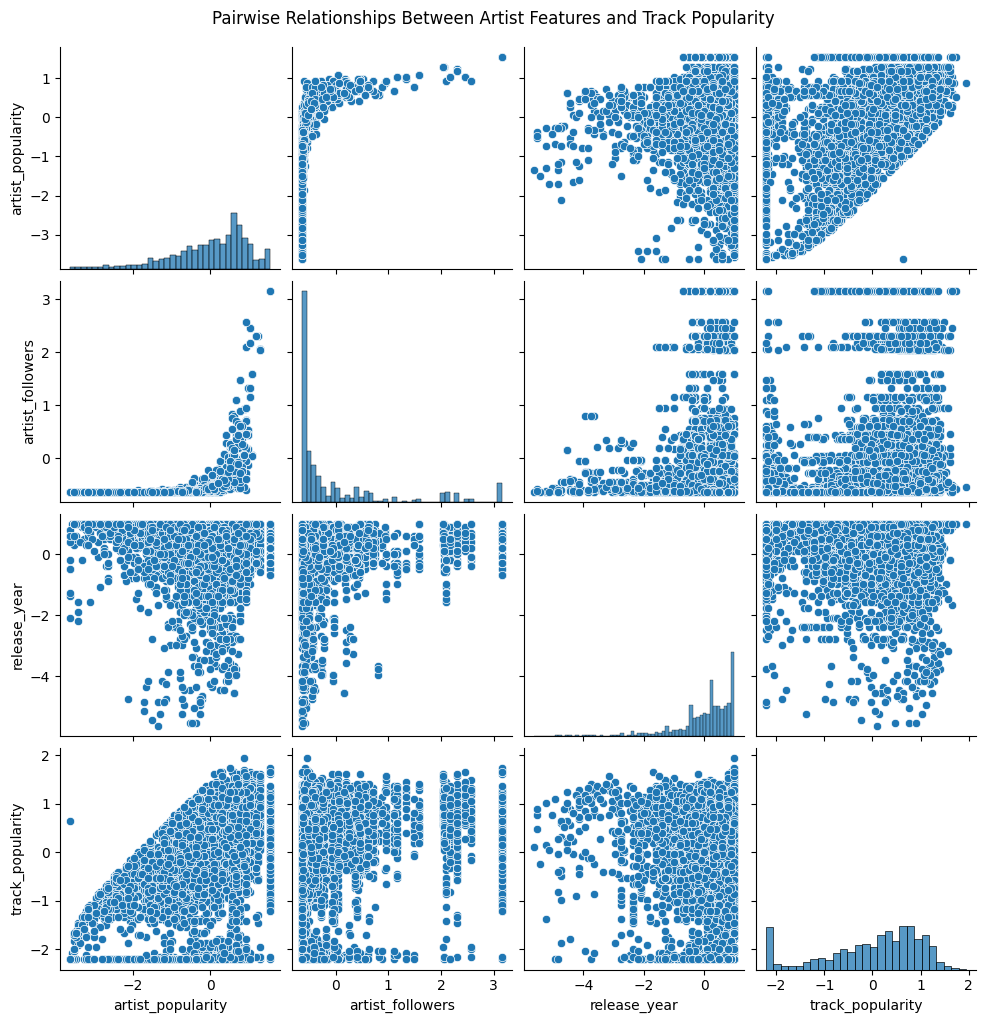

In [85]:
pairwise = sns.pairplot(pd.concat([X_train_std, Y_train_std], axis=1))
pairwise.fig.suptitle("Pairwise Relationships Between Artist Features and Track Popularity", y=1.02)


**Correlation matrix**

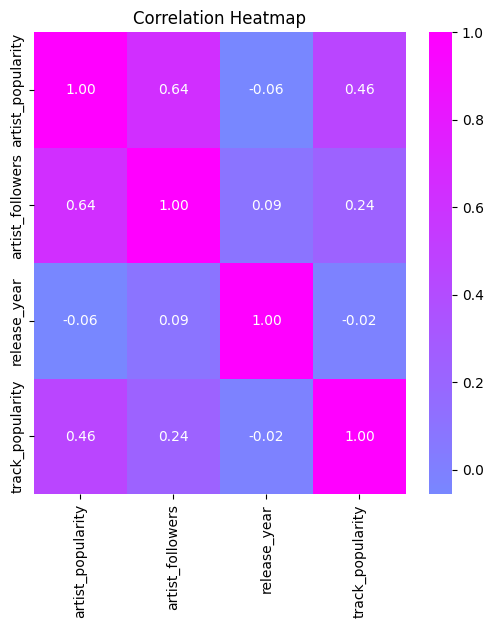

In [86]:
train_data = pd.concat([X_train_std, Y_train_std], axis=1)
train_data_corr = train_data.corr()

plt.figure(figsize=(6, 6))
sns.heatmap(
    train_data_corr,
    annot=True,
    fmt=".2f",
    cmap="cool",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

In [87]:
# Helper Function for Data Splitting: Based Year (An's Code)
def make_time_split(df, train_end, val_start, val_end, test_start):
    """Time-based split by year."""
    train = df[df["release_year"] <= train_end].copy()
    val   = df[(df["release_year"] >= val_start) & (df["release_year"] <= val_end)].copy()
    test  = df[df["release_year"] >= test_start].copy()
    return train, val, test

# Helper Function for Popularity Normalization (An's Code)

def add_pop_norm(train, val, test, target_col="track_popularity"):
    """
    Compute year_mean_pop using TRAIN only. For years not present in train
    (e.g., val/test future years), we fill with last available train mean.
    """
    year_means_train = train.groupby("release_year")[target_col].mean()
    last_train_mean = year_means_train.iloc[-1]

    for part in (train, val, test):
        part["year_mean_pop"] = part["release_year"].map(year_means_train)
        part["year_mean_pop"] = part["year_mean_pop"].fillna(last_train_mean)
        part["pop_norm"] = part[target_col] - part["year_mean_pop"]

    return train, val, test

# Helper Function for Building Feature Matrices (An's Code)

def build_feature_matrices(train, val, test, num_cols, cat_cols=[]):
    """
    Standardize numeric columns using training data only.
    """
    train_means = train[num_cols].mean()
    train_stds = train[num_cols].std()

    X_train = (train[num_cols] - train_means) / train_stds
    X_val = (val[num_cols] - train_means) / train_stds
    X_test = (test[num_cols] - train_means) / train_stds

    X_train = X_train.fillna(0)
    X_val = X_val.fillna(0)
    X_test = X_test.fillna(0)

    y_train = train["pop_norm"]
    y_val = val["pop_norm"]
    y_test = test["pop_norm"]

    return X_train, X_val, X_test, y_train, y_val, y_test, train_stds

# Define the three feature sets
feature_sets = {
    "Artist only": ["artist_popularity", "artist_followers"],
    "Song only":   ["release_year", "track_duration_min", "album_total_tracks"],
    "Artist + Song": ["artist_popularity", "artist_followers",
                      "release_year", "track_duration_min", "album_total_tracks"]
}

results = []

# create time-based split
train, val, test = make_time_split(
    df_spotify,
    train_end=2021,
    val_start=2022,
    val_end=2022,
    test_start=2023
)

# normalize popularity
train, val, test = add_pop_norm(train, val, test)

for name in feature_sets:

    X_train_s, X_val_s, X_test_s, y_train, y_val, y_test, _ = build_feature_matrices(
        train, val, test,
        num_cols=feature_sets[name],
        cat_cols=[]
    )

    model = keras.Sequential([
        keras.layers.Input(shape=(X_train_s.shape[1],)),
        keras.layers.Dense(1)
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.01),
        loss="mse",
        metrics=[
            keras.metrics.RootMeanSquaredError(name="rmse"),
            keras.metrics.MeanAbsoluteError(name="mae")
        ]
    )

    model.fit(
        X_train_s, y_train,
        validation_data=(X_val_s, y_val),
        epochs=200,
        batch_size=64,
        callbacks=[
            keras.callbacks.EarlyStopping(
                patience=15,
                restore_best_weights=True
            )
        ],
        verbose=0
    )

    _, val_rmse, val_mae = model.evaluate(X_val_s, y_val, verbose=0)
    _, test_rmse, test_mae = model.evaluate(X_test_s, y_test, verbose=0)

    results.append({
        "Model": name,
        "Features": len(feature_sets[name]),
        "Val RMSE": round(val_rmse, 2),
        "Val MAE": round(val_mae, 2),
        "Test RMSE": round(test_rmse, 2),
        "Test MAE": round(test_mae, 2)
    })

results_df = pd.DataFrame(results)

print(results_df)

           Model  Features  Val RMSE  Val MAE  Test RMSE  Test MAE
0    Artist only         2     20.56    15.59      17.08     13.45
1      Song only         3     24.95    20.03      22.60     18.65
2  Artist + Song         5     20.56    15.22      16.80     13.07


Adding to Github

In [113]:
repo_dir = "/content/datasci-207-2026-spring-project-team/src"
!git -C {repo_dir} config user.name "EwuraImpraim"
!git -C {repo_dir} config user.email "impraime@berkeley.edu"

In [117]:
repo_dir = "/content/datasci-207-2026-spring-project-team"

!git -C {repo_dir} pull origin main

From https://github.com/maimoua-lee/datasci-207-2026-spring-project-team
 * branch            main       -> FETCH_HEAD
Already up to date.


In [118]:
!git -C /content/datasci-207-2026-spring-project-team status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [119]:
repo_dir = "/content/datasci-207-2026-spring-project-team/src"

# Adding changes
!git -C {repo_dir} add ewura_project_contribution.ipynb

# Commit changes
!git -C {repo_dir} commit -m "Update Ewura project contribution notebook"

# Push changes
!git -C {repo_dir} push origin main

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date
